### Libraries

In [28]:
# Set PYTHONHASHSEED environment variable for reproducibility
import os
os.environ['PYTHONHASHSEED'] = '42'

In [29]:
import pandas as pd
import torch
import optuna
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import softmax

In [30]:
from datasets import Dataset
from transformers import BertTokenizer, TrainingArguments, Trainer
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from transformers import set_seed
from transformers import EarlyStoppingCallback

In [31]:
import optuna
from optuna.samplers import TPESampler

In [32]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.metrics import roc_curve, auc, confusion_matrix
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import classification_report, accuracy_score
import evaluate

### Setup

In [33]:
# Set path for data
data_path = "../modeldata"

Choose between 2 different sets of data with different ratios

In [34]:
# Load the datasets (Ratio of 80:10:10 for train, validation, and test sets)
train_df = pd.read_csv(f"{data_path}/train80.csv")
val_df = pd.read_csv(f"{data_path}/val10.csv")
test_df = pd.read_csv(f"{data_path}/test10.csv")

ratio = "80:10:10"

In [35]:
# Load the datasets (Ratio of 70:15:15 for train, validation, and test sets)
train_df = pd.read_csv(f"{data_path}/train70.csv")
val_df = pd.read_csv(f"{data_path}/val15.csv")
test_df = pd.read_csv(f"{data_path}/test15.csv")

ratio = "70:15:15"

In [36]:
# Ratio used
print(f"Data split ratio: {ratio}")

Data split ratio: 70:15:15


In [37]:
# REDUCE DATA SIZE FOR TESTING PURPOSES
# Uncomment the following lines to reduce the dataset size for testing purposes

train_df = train_df.sample(frac=0.1, random_state=42)
val_df = val_df.sample(frac=0.1, random_state=42)
test_df = test_df.sample(frac=0.1, random_state=42)

Once a set has been chosen, continue with next steps

In [38]:
print(train_df['label'].value_counts(normalize=True))
print(val_df['label'].value_counts(normalize=True))
print(test_df['label'].value_counts(normalize=True))

label
0    0.51218
1    0.48782
Name: proportion, dtype: float64
label
0    0.533528
1    0.466472
Name: proportion, dtype: float64
label
1    0.510204
0    0.489796
Name: proportion, dtype: float64


In [39]:
# Convert to Hugging Face format
train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)
test_dataset = Dataset.from_pandas(test_df)

In [40]:
# Set all random seeds
SEED = 42

# Set Python's built-in random seed
import random
random.seed(SEED)

# Set NumPy seed
np.random.seed(SEED)

# Set PyTorch seeds
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Set transformers seed for reproducibility
set_seed(SEED)

# Ensure deterministic behavior (especially important for reproducibility on GPU)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Use deterministic algorithms in PyTorch
torch.use_deterministic_algorithms(True)

# Set environment variable for additional determinism
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':16:8'  # or ':4294967296:8' for more memory

In [41]:
# Fixes the [WinError 3] by explicitly setting a local cache directory
cache_dir = "../huggingface_cache"
if not os.path.exists(cache_dir):
    os.makedirs(cache_dir)

# Tell Hugging Face to use this directory
os.environ['HF_HOME'] = cache_dir

# This turns off the annoying symlink warning
os.environ['HF_HUB_DISABLE_SYMLINKS_WARNING'] = '1'

### Tokenization

In [42]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
set_seed(SEED)

In [43]:
# Initiate tokenizer with the cache path
tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased', cache_dir=cache_dir)

In [44]:
# Pass tokenizer as an argument to the function
def preprocess_function(examples, tokenizer):
    return tokenizer(examples["verse"], truncation=True, padding="max_length", max_length=512)

# Tokenize the datasets
tokenized_train_dataset = train_dataset.map(preprocess_function, batched=True, num_proc=1, fn_kwargs={'tokenizer': tokenizer})
tokenized_val_dataset = val_dataset.map(preprocess_function, batched=True, num_proc=1, fn_kwargs={'tokenizer': tokenizer})
tokenized_test_dataset = test_dataset.map(preprocess_function, batched=True, num_proc=1, fn_kwargs={'tokenizer': tokenizer})

Map (num_proc=1): 100%|██████████| 343/343 [00:11<00:00, 29.31 examples/s]


In [45]:
print(tokenized_train_dataset)
print(tokenized_val_dataset)
print(tokenized_test_dataset)

Dataset({
    features: ['verse', 'label', '__index_level_0__', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 1601
})
Dataset({
    features: ['verse', 'label', '__index_level_0__', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 343
})
Dataset({
    features: ['verse', 'label', '__index_level_0__', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 343
})


### Model Setup

In [46]:
# Reset seed for model training
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
set_seed(SEED)

In [47]:
model_name = "distilbert-base-uncased" # From the Hugging Face Hub

# 1. Load the tokenizer (must match the model)
tokenizer = AutoTokenizer.from_pretrained(model_name)

# 2. Load the model with a classification head
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 3082.37it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [48]:
# Function to initialize the model for the Trainer, useful for hyperparameter tuning
def model_init():
    set_seed(42)  # Ensure reproducibility
    torch.manual_seed(42)
    torch.cuda.manual_seed_all(42)
    return AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)


In [49]:
# Define the compute_metrics function for evaluation
metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="binary"   # For binary classification
    )

    accuracy = accuracy_score(labels, predictions)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

### Hyperparameter Tuning

In [50]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
set_seed(SEED)

In [51]:
def objective(trial):
    try:
        learning_rate = trial.suggest_categorical("learning_rate", [1e-5, 2e-5, 5e-5])
        per_device_train_batch_size = trial.suggest_categorical("per_device_train_batch_size", [8, 16, 32])
        weight_decay = trial.suggest_categorical("weight_decay", [0.0, 0.01, 0.1])
        
        # Reset seeds BEFORE trainer
        set_seed(42)
        torch.manual_seed(42)
        torch.cuda.manual_seed_all(42)
        
        trial_training_args = TrainingArguments(
            output_dir=f"./results/trial_{trial.number}",  # ← UNIQUE per trial!
            eval_strategy="epoch",
            save_strategy="epoch",
            learning_rate=learning_rate,
            per_device_train_batch_size=per_device_train_batch_size,
            per_device_eval_batch_size=16,
            num_train_epochs=3,
            weight_decay=weight_decay,
            load_best_model_at_end=True,
            metric_for_best_model="eval_accuracy",
            greater_is_better=True,
            report_to="none",
            seed=42,
            data_seed=42,
            dataloader_num_workers=0,
            fp16=torch.cuda.is_available(),
            disable_tqdm=True
        )
        
        trial_trainer = Trainer(
            model=model_init(),
            args=trial_training_args,
            train_dataset=tokenized_train_dataset,
            eval_dataset=tokenized_val_dataset,
            compute_metrics=compute_metrics,
        )

        # Train and evaluate the model for this trial
        print(f"\n\n=== TRIAL {trial.number} (learning_rate={learning_rate}, batch_size={per_device_train_batch_size}, weight_decay={weight_decay}) ===\n")
        trial_trainer.train()
        eval_result = trial_trainer.evaluate()
        accuracy = eval_result["eval_accuracy"]
        
        return accuracy
        
    except Exception as e:
        print(f"Trial {trial.number} failed: {e}")
        return None

In [52]:
sampler = TPESampler(seed=42)

# Create a study and run the hyperparameter search
study = optuna.create_study(study_name="distilbert_tuning", direction="maximize", sampler=sampler)
study.optimize(objective, n_trials=10)

best_trial = study.best_trial

[I 2026-08-15 19:20:03,138] A new study created in memory with name: distilbert_tuning
Loading weights: 100%|██████████| 100/100 [00:00<00:00, 4201.19it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.




=== TRIAL 0 (learning_rate=2e-05, batch_size=8, weight_decay=0.01) ===

{'eval_loss': '0.3871', 'eval_accuracy': '0.8222', 'eval_precision': '0.8722', 'eval_recall': '0.725', 'eval_f1': '0.7918', 'eval_runtime': '2.981', 'eval_samples_per_second': '115.1', 'eval_steps_per_second': '7.38', 'epoch': '1'}


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.91it/s]
[W 2026-08-15 19:21:20,295] Trial 0 failed with parameters: {'learning_rate': 2e-05, 'per_device_train_batch_size': 8, 'weight_decay': 0.01} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "c:\Users\User\Documents\devanasokan_fyp\.venv\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "C:\Users\User\AppData\Local\Temp\ipykernel_46444\3227891061.py", line 42, in objective
    trial_trainer.train()
    ~~~~~~~~~~~~~~~~~~~^^
  File "c:\Users\User\Documents\devanasokan_fyp\.venv\Lib\site-packages\transformers\trainer.py", line 1424, in train
    return inner_training_loop(
        args=args,
    ...<2 lines>...
        ignore_keys_for_eval=ignore_keys_for_eval,
    )
  File "c:\Users\User\Documents\devanasokan_fyp\.venv\Lib\site-packages\transformers\trainer.py", line 1506, in _inner_training_loop
    self._run_epoch

KeyboardInterrupt: 

In [ ]:
print("============================ RESULTS ============================")
print(f"\nBest Trial: {best_trial.number}, Accuracy: {best_trial.value:.4f}")
print(f"Best Hyperparameters: {best_trial.params}")

In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
set_seed(SEED)

In [ ]:
# Get the best hyperparameters and set up the final training arguments
final_training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=best_trial.params["learning_rate"],
    per_device_train_batch_size=best_trial.params["per_device_train_batch_size"],
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=best_trial.params["weight_decay"],
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,
    report_to="none",
    seed=42,
    data_seed=42,                     # For reproducibility of data shuffling
    dataloader_num_workers=0,        # For single-process loading
    fp16=torch.cuda.is_available(),
)

In [ ]:
# Initialize the final Trainer with the best hyperparameters
final_trainer = Trainer(
    model=model_init(),
    args=final_training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_val_dataset,
    compute_metrics=compute_metrics,
)

# Train the final model with the best hyperparameters
final_trainer.train()

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 5803.90it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,No log,0.385928,0.819242,0.865672,0.725000,0.789116
2,No log,0.481978,0.804665,0.748663,0.875000,0.806916
3,0.335042,0.522844,0.833819,0.804734,0.850000,0.826748


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.35it/s]
There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=603, training_loss=0.30211179489717754, metrics={'train_runtime': 100.6551, 'train_samples_per_second': 47.717, 'train_steps_per_second': 5.991, 'total_flos': 636240915744768.0, 'train_loss': 0.30211179489717754, 'epoch': 3.0})

In [ ]:
# might not need
history = pd.DataFrame(final_trainer.state.log_history)
print(history)

   eval_loss  eval_accuracy  eval_precision  eval_recall   eval_f1  \
0   0.385928       0.819242        0.865672        0.725  0.789116   
1   0.481978       0.804665        0.748663        0.875  0.806916   
2        NaN            NaN             NaN          NaN       NaN   
3   0.522844       0.833819        0.804734        0.850  0.826748   
4        NaN            NaN             NaN          NaN       NaN   

   eval_runtime  eval_samples_per_second  eval_steps_per_second     epoch  \
0        2.0390                  168.218                 10.790  1.000000   
1        1.7153                  199.960                 12.825  2.000000   
2           NaN                      NaN                    NaN  2.487562   
3        1.5898                  215.752                 13.838  3.000000   
4           NaN                      NaN                    NaN  3.000000   

   step      loss  grad_norm  learning_rate  train_runtime  \
0   201       NaN        NaN            NaN           

### Model Evaluation

In [ ]:
# Evaluate the model on the test set
predictions = final_trainer.predict(tokenized_test_dataset)

In [ ]:
# Save the predictions to a CSV file
predictions_df = pd.DataFrame({
    'verse': tokenized_test_dataset["verse"],
    'true_label': predictions.label_ids,
    'predicted_label': np.argmax(predictions.predictions, axis=-1)
})
predictions_df.to_csv("../evaluation/tuned_distilbert_predictions.csv", index=False)

In [ ]:
# Extract logits and true labels
logits = predictions.predictions
y_true = predictions.label_ids

# Convert logits to predicted classes
y_pred = np.argmax(predictions.predictions, axis=-1)

In [ ]:
# Calculate probabilities using softmax
probabilities = softmax(logits, axis=1)

# Get the probabilities for the positive class (label 1)
y_scores = probabilities[:, 1]

#### Classification Report

In [ ]:
report = classification_report(
    y_true,
    y_pred,
    output_dict=True
)

accuracy = accuracy_score(y_true, y_pred)
precision = report["1"]["precision"]
recall = report["1"]["recall"]
f1 = report["1"]["f1-score"]

print(f"DISTILBERT CLASSIFICATION REPORT (TUNING - {ratio}):")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

DISTILBERT CLASSIFICATION REPORT (TUNING - 70:15:15):
Accuracy: 0.8221574344023324
Precision: 0.8392857142857143
Recall: 0.8057142857142857
F1-score: 0.8221574344023324


#### ROC-AUC Curve

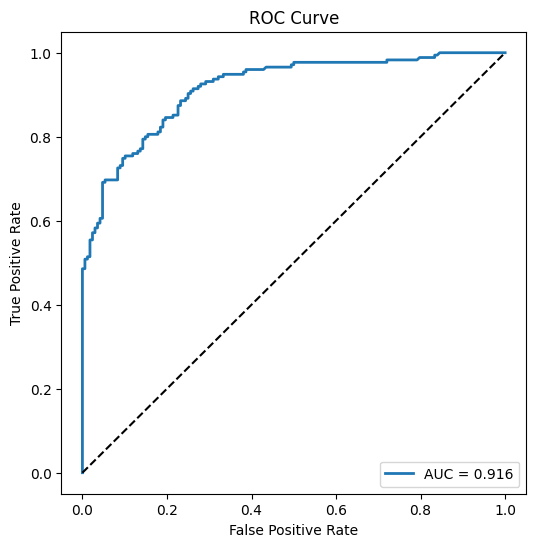

In [ ]:
fpr, tpr, thresholds = roc_curve(y_true, y_scores)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.3f}",
    linewidth=2
)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")

plt.show()

#### Precision-Recall Curve

PR-AUC: 0.9281781063428514


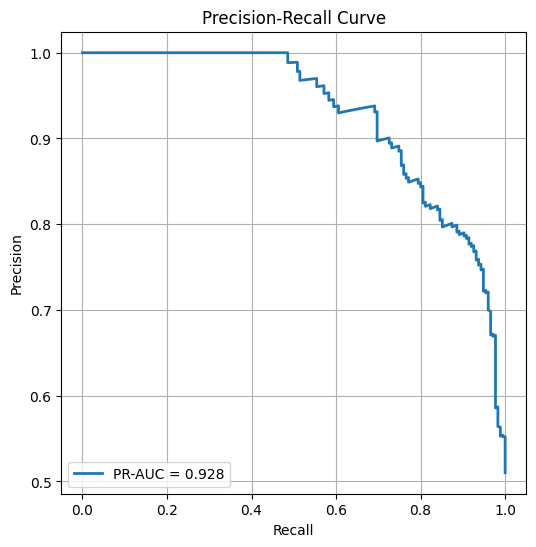

In [ ]:
precision, recall, thresholds = precision_recall_curve(
    y_true,
    y_scores
)

pr_auc = auc(recall, precision)

print("PR-AUC:", pr_auc)

plt.figure(figsize=(6,6))

plt.plot(
    recall,
    precision,
    label=f"PR-AUC = {pr_auc:.3f}",
    linewidth=2
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.legend(loc="lower left")
plt.grid()

#### Confusion Matrix

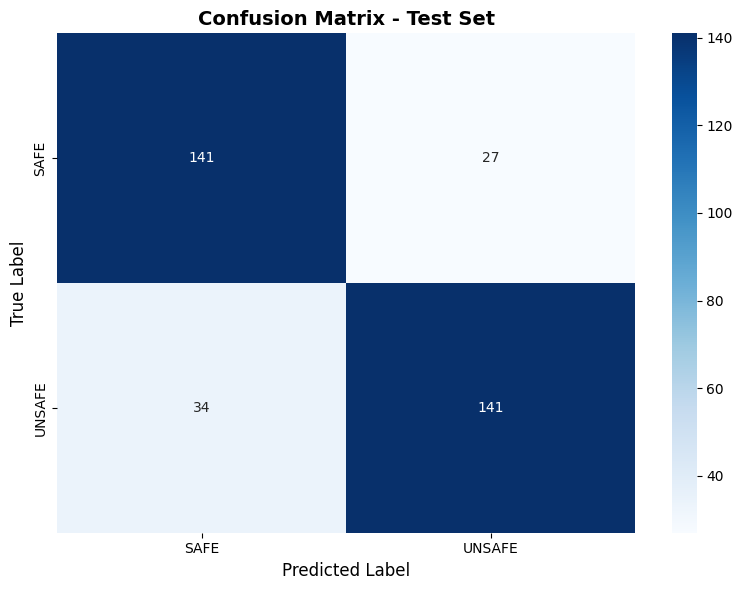

In [ ]:
# Calculate confusion matrix
cm = confusion_matrix(y_true, y_pred)
 
# Create the plot
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, 
    annot=True,  # Show numbers in cells
    fmt='d',     # Format as integers
    cmap='Blues',  # Color palette
    cbar=True,   # Show color bar
    xticklabels=['SAFE', 'UNSAFE'],
    yticklabels=['SAFE', 'UNSAFE']
)
 
plt.title('Confusion Matrix - Test Set', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

### Save Model and Test

In [ ]:
# Save the version currently in the final trainer's brain
final_trainer.save_model("./my_final_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.35it/s]


In [ ]:
# TEST MODEL

from transformers import AutoModelForSequenceClassification, AutoTokenizer, pipeline

# Load the model and tokenizer from your local folder
path = "./my_final_distilbert"
model = AutoModelForSequenceClassification.from_pretrained(path)
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased") # Ensure you saved the tokenizer there too!

# Create a 'pipeline' (the easiest way to use the model)
classifier = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 4194.71it/s]


In [ ]:
# Test it on a new sentence
result = classifier("kiss it from my lips")
print(result)

[{'label': 'LABEL_1', 'score': 0.9105663299560547}]


In [ ]:
import accelerate
import transformers
import torch

print(f"Accelerate version: {accelerate.__version__}")
print(f"Transformers version: {transformers.__version__}")

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("GPU:", torch.cuda.get_device_name(0))

Accelerate version: 1.13.0
Transformers version: 5.3.0
Torch version: 2.7.1+cu118
CUDA available: True
CUDA version: 11.8
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
